# Constraint Satisfaction Problem (CSP)

## Overview of the lab
In this lab, we will explore constraint satisfaction problems (CSPs). These problems can be defined as a set of variables, each with an associated domain of possible values, along with constraints that restrict the combinations of values the variables can simultaneously take. CSPs are often computationally difficult to solve, frequently exhibiting exponential time complexity $O(mⁿ)$ and belonging to NP-complete or NP-hard classes. Therefore, instead of always seeking an optimal solution, we often aim to find solutions that are sufficiently good within reasonable computational limits.

### Examples
- Assignment problems
- Timetabling problems
- Transportation scheduling

## 1. Introduction to Constraint Satisfaction Problems (CSP)
Unlike search problems, CSPs are a type of identification problem, problems in which we must **simply identify whether a state is a goal state or not**, with no regard to how we arrive at that goal. CSPs are defined by three factors:
1. *Variables*  - CSPs possess a set of $N$ variables $X_1, ..., X_N$ that can each take on a single value from some defined set of values.
2.  *Domain* - A set $ {x_1,..., x_d} $ representing all possible values that a CSP variable can take on. 
3. *Constraints* - Constraints define restrictions on the values of variables, potentially with regard to other variables.

Shortly CSP:
* state is defined by variables $X_i$ with values from domain $D_i$
* goal test is a set of constraints specifying allowable combinations of values for subsets of variables

### Example: Map coloring

Map coloring solves the problem where we’re given a set of colors and must color a map such that no two adjacent states or regions have the same color.


![image.png](images/map_coloring_problem.png)

### Variables: 
- ***WA, NT, Q, NSW, V, SA, T***
### Domains:  
- ***$D_i$ = {red, green, blue}***
### Constraints: 
- Adjacent regions must have different colors e.g., WA ≠ NT (if the language allows this), or (WA, NT) ∈ {(red, green),(red, blue),(green, red),(green, blue), . . .}
### Solutions:
- Solutions are assignments satisfying all constraints, e.g., {WA = red, NT = green, Q = red, NSW = green, V = red, SA = blue, T = green}

![image.png](images/map_coloring_problem_solved.png)

### Constraint graph
Constraint satisfaction problems are often represented as constraint graphs, where nodes represent variables and edges represent constraints between them. There are many different types of constraints, and each is handled slightly differently:
* ***Unary Constraints*** - involve a single variable in the CSP. They are not represented in constraint graphs, instead simply being used to prune the domain of the variable they constrain when necessary. eg. $SA \neq green$
* ***Binary Constraints*** - Binary constraints involve two variables. They’re represented in constraint graphs as traditional graph edges. e.g. $ SA \neq WA$
* ***Higher-order Constraints*** - Constraints involving three or more variables can also be represented with edges in a CSP graph.

e.g University Course Timetabling CSP - The variables are the assignment of a time slot and a room to each class (e.g., specific lectures, tutorials, and labs).
   * $V = \{ C_1, C_2, ..., C_n \}$
   * The domain for each variable $C_i$ is a set of possible (Time Slot, Room) pairs, but other things should be take into account, which leads to a high-order constarints.

1. **Maximum Capacity Constraint (Order $k \ge 3$)**: This constraint ensures that the total number of students scheduled to be in the same room at the same time does not exceed the room's maximum capacity.
   * Room ($R$): The capacity is a property of the room.
   * Time Slot ($T$): The simultaneous usage.
   * Classes ($C_i, C_j, \dots$): The classes assigned to that room and time.
   
2. **Professor/Student Availability and Load Constraints (Order $\ge 3$)**:Constraints related to the workload or availability of a single resource (like a professor or a pool of shared equipment) across multiple classes. 
   * Professor ($P$): A shared resource.
   * Classes ($C_i, C_j, C_k, \dots$): The classes taught by that professor.
   * Time Slots ($T_i, T_j, T_k, \dots$): The scheduled times.
   * Constraint Example (Conceptual): A professor $P$ cannot teach more than 3 classes on any given day, or they must have a 1-hour break between consecutive classes.

* ***Preferences (soft constraints)*** - e.g., red is better than green often representable by a cost for each variable assignment → constrained optimization problems

**Example of the Constraint graph for the Map coloring problem.
The constraints in this problem are simply that no two adjacent states can be the same color. As a result, by drawing an edge between every pair of states that are adjacent to one another, we can generate the constraint graph for the map coloring of Australia as follows:**

![image.png](images/constraint_graph.png)

## 2. Solving Constraint Satisfaction Problems

Constraint satisfaction problems are traditionally solved using **backtracking**. Backtracking is an optimization on depth-first search used specifically for the problem of constraint satisfaction, with improvements coming from two main principles:
1. **Fix an ordering for variables**, and select values for variables in this order. Because assignments are commutative (e.g. assigning $WA = Red, NT = Green$ is identical to $NT = Green, WA = Red$)
2. When selecting values for a variable, **only select values that don’t conflict with any previously assigned values**. If no such values exist, backtrack and return to the previous variable, changing its value.

The most used techniques are variants of:
* Backtracking (Depth-First Search)
* Constraint Propagation
   * Forward checking
   * Arc consistency (ac3 algorithm) - for more watch this video [here](https://www.youtube.com/watch?v=4cCS8rrYT14)
* Local Search
   * minConflict (Hill Climbing)

* ***Minimum Remaining Values (MRV)*** - When selecting which variable to assign next, using an MRV policy chooses whichever unassigned variable has the fewest valid remaining values (the most constrained variable). This is intuitive in the sense that the most constrained variable is most likely to run out of possible values and result in backtracking if left unassigned, and so it’s best to assign a value to it sooner than later.
* ***Least Constraining Value (LCV)*** - Similarly, when selecting which value to assign next, a good policy to implement is to select the value that prunes the fewest values from the domains of the remaining unassigned values. Notably, this requires additional computation (e.g. rerunning arc consistency/forward checking or other filtering methods for each value to find the LCV), but can still yield speed gains depending on usage.

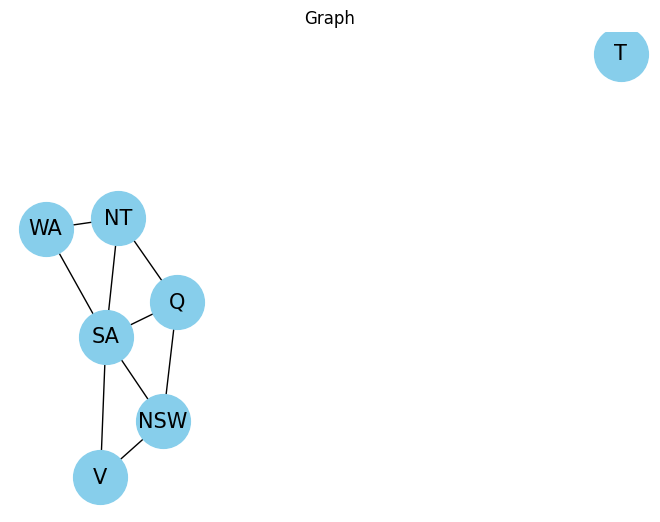

In [1]:
from utils import Graph
edges = {
    "WA":[("NT",1),("SA",1)],
    "NT":[("WA",1),("SA",1),("Q",1)],
    "SA":[("NT",1),("Q",1),("NSW",1),("V",1),("WA",1)],
    "Q":[("NT",1),("SA",1),("NSW",1)],
    "NSW":[("SA",1),("V",1),("Q",1)],
    "V":[("SA",1),("NSW",1)],
    "T":[]
}
nodes = ["WA","NT","Q","NSW","V","SA","T"]

graph = Graph(nodes,edges)
graph.show(show_weights=False)

In [ ]:
def backtracing(current_variable, remaining_variables, edges, domain, current_state={}):
    
    for value in domain:
        is_acceptable = True
        # Check if neighbouring variables have the same value
        for neighbour,cost in edges[current_variable]:
            if neighbour in current_state and current_state[neighbour] == value:
                is_acceptable=False
                break
        
        if is_acceptable:

            current_state[current_variable] = value
            if not remaining_variables:
                return current_state
            
            next = remaining_variables[0]
            result = backtracing(next, remaining_variables[1:], edges, domain, current_state)
            if result != None:
                return result
            
            current_state.pop(current_variable)

    return None

def solve(nodes, edges, domain):
    return backtracing(nodes[0], nodes[1:], edges, domain)

In [ ]:
res = solve(nodes, edges, ["red","green","blue"])
res

{'WA': 'red',
 'NT': 'green',
 'Q': 'red',
 'NSW': 'green',
 'V': 'red',
 'SA': 'blue',
 'T': 'red'}

This solution is almost the same as the one above: 
{WA = red, NT = green, Q = red, NSW = green, V = red, SA = blue, T = green}

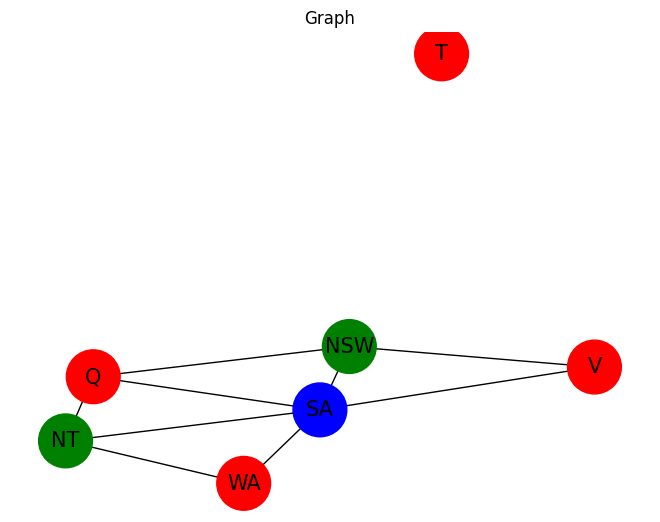

In [4]:
graph.show(show_weights=False,node_color=list(res.values()))

## 3. Min-conflicts
Start with some random assignment to values, then **iteratively select a random conflicted variable and reassign its value to the one that violates the fewest constraints until no more constraint violations exist** (a policy known as the min-conflicts heuristic).
Under such a policy, constraint satisfaction problems like N-queens become both very time-efficient and space-efficient to solve.

In [ ]:
import numpy as np


def random_assignment(variables, domain):
    return {variable: np.random.choice(domain).item() for variable in variables}


def count_conflicts(variables, edges, state):
    conflicts = {}
    for variable in variables:
        for neighbour, cost in edges[variable]:
            if state[neighbour] == state[variable]:
                conflicts[variable] = conflicts.get(variable, 0) + 1
    return conflicts


def get_value_with_least_conflicts(variable, edges, domain, state):
    best_value = None
    best_conflicts_count = float("inf")
    for value in domain:
        conflicts = 0
        for neighbour, cost in edges[variable]:
            if state[neighbour] == value:
                conflicts += 1

        if conflicts < best_conflicts_count:
            best_conflicts_count = conflicts
            best_value = value

    return best_value


def min_conflicts(variables, edges, domain, random_restart_steps=300):
    state = random_assignment(variables, domain)
    steps = 0
    while True:
        # We don't need to recalculate all conflicts on every iteration.
        # Instead, we can initialize the conflict dictionary once and update only
        # the conflicts involving the variable we changed and its neighbours.
        conflicts = count_conflicts(variables, edges, state)

        if len(conflicts) == 0:
            break

        # Instead of picking a random variable, we can pick the one with the most conflicts
        to_swap = np.random.choice(list(conflicts.keys())).item()
        #to_swap = max(conflicts, key=conflicts.get)
        new_value = get_value_with_least_conflicts(
            to_swap, edges, domain, state)

        state[to_swap] = new_value

        steps += 1
        if steps >= random_restart_steps:
            state = random_assignment(variables, domain)
            steps = 0
    return state

In [12]:
res = min_conflicts(nodes,edges,["red","green","blue"])
res

{'WA': 'green',
 'NT': 'blue',
 'Q': 'green',
 'NSW': 'blue',
 'V': 'green',
 'SA': 'red',
 'T': 'green'}

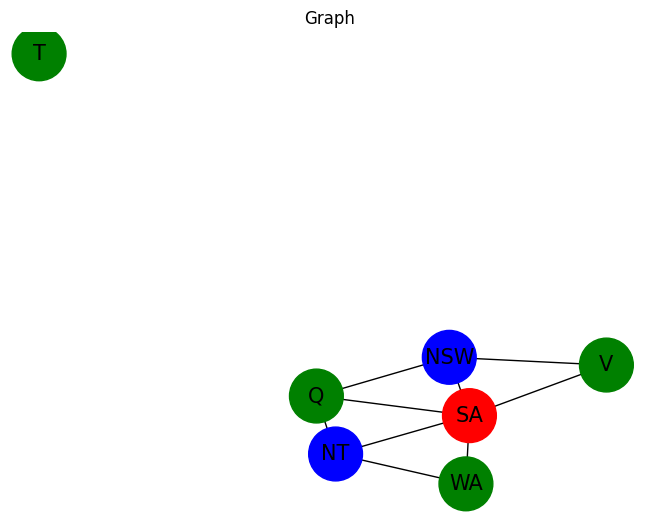

In [13]:
graph.show(show_weights=False,node_color=list(res.values()))

## 4. N-queens Problem
The eight queens puzzle is the problem of placing eight chess queens on
an 8×8 chessboard so that no two queens threaten each other; thus, a
solution requires that no two queens share the same row, column, or
diagonal. The eight queens puzzle is an example of the more general n
queens problem of placing n non-attacking queens on an n×n chessboard,
for which solutions exist for all natural numbers n with the exception of $n=2$ and $n=3$.

For the homework the algorithm should be able to solve the n-queens problem for up to $n=10000$

Solution for $n=1000000$ are possible with a well tuned min-conflict algorithm.

### Solving N-queens

Start with some random assignment to values, then **iteratively select a random(or the one with most conflicts) conflicted variable and reassign its value to the one that violates the fewest constraints until no more constraint violations exist** (a policy known as the min-conflicts heuristic).
Under such a policy, constraint satisfaction problems like N-queens become both very time-efficient and space-efficient to solve.

The whole algorithm should look something like this:


1. Initialize the starting positions of the queens randomly 
2. Until the number of consflicts is zero 
    * take a random conflicted queen and remove her from the current row
    * calculate the number of conflicts by positing the queen at $row_i$ for all $i = 0, ..., n-1$
    * for all rows that the count of the conflicts is minimal, choose a random one to place the queen

For example, in the following example with 4 queens, we arrive at a solution after only 2 iterations:


![queens](images/n_queens_min_conflict.png)

$h(n)$ = number of attacks

$n$ = the size of the board

### Board Representation

Each queen should be in different column. We will represent the queens by the column they are in. $Queen_0$ in $column_0$, $Queen_1$ in $column_1$ ... $Queen_N$ in $column_N$. This way we can store the queens in a array of n number. The number at position $i$ would indicate at which row the queen at the column $i$ is place: $Queen_i$. We can call this array $queenPosition$.

Example for a board:

![queens](images/NQueensStoring.png)

### Board Initialization
**Random initialization** – The simplest and most intuitive approach is to initialize the board by placing queens at random positions.

**Enforce one queen per row** – A fully random initialization is likely to place multiple queens in the same row. We can simplify the initial state by enforcing the constraint that each row contains exactly one queen. This reduces the search space and significantly decreases the initial number of conflicts. 

**Min-conflicts initialization** – This more complex approach uses a DFS algorithm to construct a board with as few conflicts as possible from the start. It greedily places queens while ensuring that each new queen introduces no conflicts with the queens already placed. If the algorithm reaches a dead end where no valid placement is possible, it randomly initializes the remaining queens. For larger values of $n$, this approach can become a bottleneck, as the algorithm may spend considerable time trying to find a valid position for each queen.

**Knight initialization** – There is a pattern based on the movement of a knight chess piece that can be used to initialize the board with relatively few conflicts. By placing queens according to this pattern, we can often obtain a good starting configuration. For certain values of $n$, following the pattern can even produce a valid solution directly.

Solution that follows the knight moves:

![knightInitialization](images/NQueensKnightInitialization.png)


### Max-Min-Conflicts algorithm

The standard min-conflicts algorithm selects a queen at random and moves it to a position that reduces the number of conflicts. An optimization is to select the queen with the highest number of conflicts and move it to the position within its column that results in the fewest conflicts. Although this strategy can improve the algorithm's overall performance, it can also get stuck in loops or local optima.

To address this issue, the algorithm randomly selects a queen among those with the highest number of conflicts. It then randomly chooses a position among those that result in the fewest conflicts. This can handle most of the situations with loops, but it still provides no guaranties.

Another way to handle this problem, it is often combined with an approach called **Random Restart**, which restarts the algorithm with a new initial configuration whenever progress stalls.

### Random Restart

This technique restarts the algorithm with a new initial configuration whenever the iteration count reaches a predefined threshold. It helps the algorithm escape poor starting configurations and avoid spending too much time exploring unproductive search paths.

### Conflict Tracking
To track the conflict and in which row $Queen_i$ is positioned we will use the following arrays:
 * $queenPosition$ - keeps track in which row is $Queen_i$
 * $conflictRows$ - number of queens in each row
 * $conflictPositiveDiagonals$ - number of queens in each positive diagonal
 * $conflictNegativeDiagonals$ - number of queens in each negative diagonal

The number of positive/negative diagnals in $n$ x $n$ matrix is $2*n-1$
* Accessing the $ith$ positive diagonal: $(row + col)$
* Accessing the $ith$ negative diagonal: $(n - 1 -row + col)$

$h(n)$ = total number of conflicts on the board

Example of how the diagonals are calculated:
![Diagonals](images/NQueensDiagonalStoring.png)


## PseudoCode
```
solve(N){
    // Putting the queen on the row with min conflicts
    queens[] = init(N)
    iter = 0
    while(iter++ <= k*N){
        // Randomly if two or more!
        col = getColWithQueenWithMaxConf()
        // Randomly if two or more!
        row = getRowWithMinConflict(col)
        // index=col & value=row
        queens[col] = row
    }
    if(hasConflicts()){
        // Restart
        solve(N)
    }
}
```